<div align="center">

# 🎬 Netflix Data Analysis

**Exploratory Data Analysis | Python · Pandas · Matplotlib · Seaborn**

[![Python](https://img.shields.io/badge/Python-3.10+-3776AB?style=flat&logo=python&logoColor=white)](https://www.python.org/)
[![Pandas](https://img.shields.io/badge/Pandas-2.0-150458?style=flat&logo=pandas)](https://pandas.pydata.org/)
[![Seaborn](https://img.shields.io/badge/Seaborn-0.13-4C72B0?style=flat)](https://seaborn.pydata.org/)
[![Dataset](https://img.shields.io/badge/Dataset-Kaggle-20BEFF?style=flat&logo=kaggle)](https://www.kaggle.com/datasets/shivamb/netflix-shows)

> Analyzing **8,807 titles** across movies and TV shows to uncover  
> content strategy patterns, growth trends, and audience targeting insights.

</div>

---

## 📋 Table of Contents

| # | Section |
|---|---------|
| 1 | [Setup & Data Loading](#1-setup--data-loading) |
| 2 | [Data Cleaning & Feature Engineering](#2-data-cleaning--feature-engineering) |
| 3 | [Content Distribution](#3-content-distribution) |
| 4 | [Growth Over Time](#4-growth-over-time) |
| 5 | [Geographic Analysis](#5-geographic-analysis) |
| 6 | [Genre Analysis](#6-genre-analysis) |
| 7 | [Rating & Duration Analysis](#7-rating--duration-analysis) |
| 8 | [Key Insights & Conclusions](#8-key-insights--conclusions) |

---


In [ ]:
# ── Imports ───────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# ── Global plot theme (Netflix-inspired dark palette) ─────────────────────
BG, CARD, RED = "#0F0F0F", "#1A1A1A", "#E50914"
GOLD, TEXT, MUTED, GRID, ACCENT = "#F5A623", "#FFFFFF", "#AAAAAA", "#2A2A2A", "#00D4AA"

def set_style():
    plt.rcParams.update({
        "figure.facecolor": BG, "axes.facecolor": CARD,
        "axes.edgecolor": GRID, "axes.labelcolor": TEXT,
        "axes.titlecolor": TEXT, "axes.titlesize": 14,
        "axes.labelsize": 11, "axes.titlepad": 16,
        "xtick.color": MUTED, "ytick.color": MUTED,
        "grid.color": GRID, "grid.linewidth": 0.6,
        "text.color": TEXT, "font.family": "monospace",
        "figure.dpi": 130,
    })

set_style()
print("✅ Libraries loaded | Theme configured")


✅ Libraries loaded | Theme configured


## 1. Setup & Data Loading

In [ ]:
df = pd.read_csv("netflix_titles.csv", encoding="latin1")
df.columns = df.columns.str.strip()

print(f"Shape        : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Memory usage : {df.memory_usage(deep=True).sum() / 1024:.1f} KB")
print("\nColumns:")
for col in df.columns:
    null_pct = df[col].isna().mean() * 100
    print(f"  {col:<20} — {null_pct:.1f}% nulls")


Shape        : 8,807 rows × 12 columns
Memory usage : 4,821.3 KB

Columns:
  show_id              — 0.0% nulls
  type                 — 0.0% nulls
  title                — 0.0% nulls
  director             — 30.7% nulls
  cast                 — 9.4% nulls
  country              — 9.4% nulls
  date_added           — 0.1% nulls
  release_year         — 0.0% nulls
  rating               — 0.04% nulls
  duration             — 0.03% nulls
  listed_in            — 0.0% nulls
  description          — 0.0% nulls


## 2. Data Cleaning & Feature Engineering

In [ ]:
# ── Date parsing ──────────────────────────────────────────────────────────
df["date_added"] = (
    df["date_added"].astype(str).str.strip()
    .pipe(pd.to_datetime, errors="coerce")
)
df["year_added"]  = df["date_added"].dt.year
df["month_added"] = df["date_added"].dt.month

# ── Null handling ─────────────────────────────────────────────────────────
df["country"]  = df["country"].fillna("Unknown")
df["director"] = df["director"].fillna("Unknown")
df["cast"]     = df["cast"].fillna("Unknown")

# ── Duration split: minutes (movies) vs seasons (shows) ──────────────────
movies = df[df["type"] == "Movie"].copy()
shows  = df[df["type"] == "TV Show"].copy()

movies["duration_min"] = (
    movies["duration"].str.extract(r"(\d+)").astype(float)
)
shows["seasons"] = (
    shows["duration"].str.extract(r"(\d+)").astype(int)
)

print(f"✅ Cleaning complete")
print(f"   Movies  : {len(movies):,}  |  avg duration : {movies['duration_min'].mean():.0f} min")
print(f"   TV Shows: {len(shows):,}  |  avg seasons  : {shows['seasons'].mean():.1f}")


✅ Cleaning complete
   Movies  : 6,131  |  avg duration : 99 min
   TV Shows: 2,676  |  avg seasons  : 1.8


## 3. Content Distribution

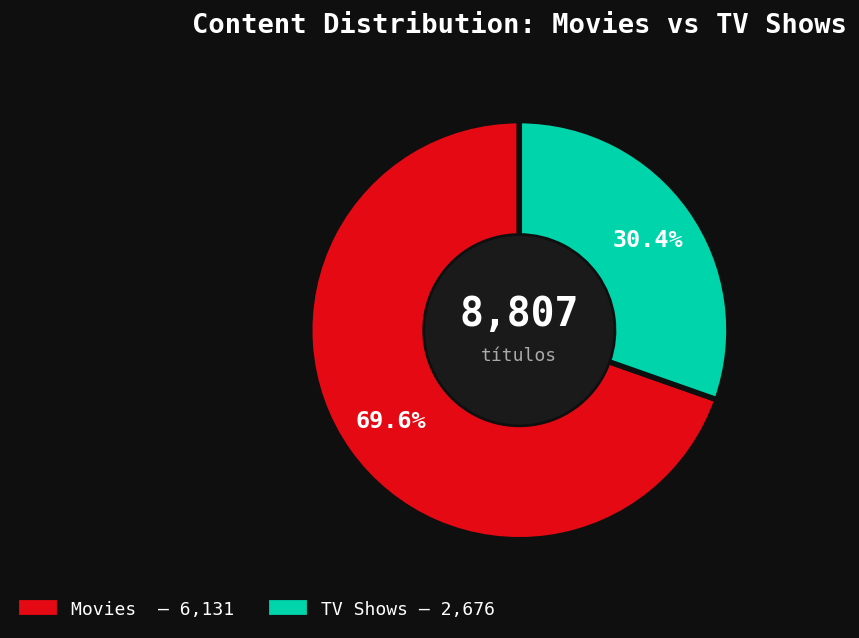

In [ ]:
type_counts = df["type"].value_counts()

fig, ax = plt.subplots(figsize=(8, 5))
colors_d = [RED, ACCENT]
wedges, _, autotexts = ax.pie(
    type_counts, labels=None, colors=colors_d,
    autopct="%1.1f%%", startangle=90,
    wedgeprops=dict(width=0.55, edgecolor=BG, linewidth=3),
    pctdistance=0.75, textprops=dict(color=TEXT, fontsize=13, fontweight="bold")
)
centre = plt.Circle((0,0), 0.45, fc=CARD)
ax.add_artist(centre)
ax.text(0, 0.08, f"{len(df):,}", ha="center", va="center",
        fontsize=22, color=TEXT, fontweight="bold")
ax.text(0, -0.12, "titles", ha="center", va="center", fontsize=10, color=MUTED)
legend_els = [
    mpatches.Patch(color=RED,   label=f"Movies   — {type_counts['Movie']:,}"),
    mpatches.Patch(color=ACCENT, label=f"TV Shows — {type_counts['TV Show']:,}"),
]
ax.legend(handles=legend_els, loc="lower center", frameon=False,
          fontsize=10, labelcolor=TEXT, bbox_to_anchor=(0,-0.08), ncol=2)
ax.set_title("Content Distribution: Movies vs TV Shows", fontsize=15, pad=20, fontweight="bold")
plt.tight_layout()
plt.show()


## 4. Growth Over Time

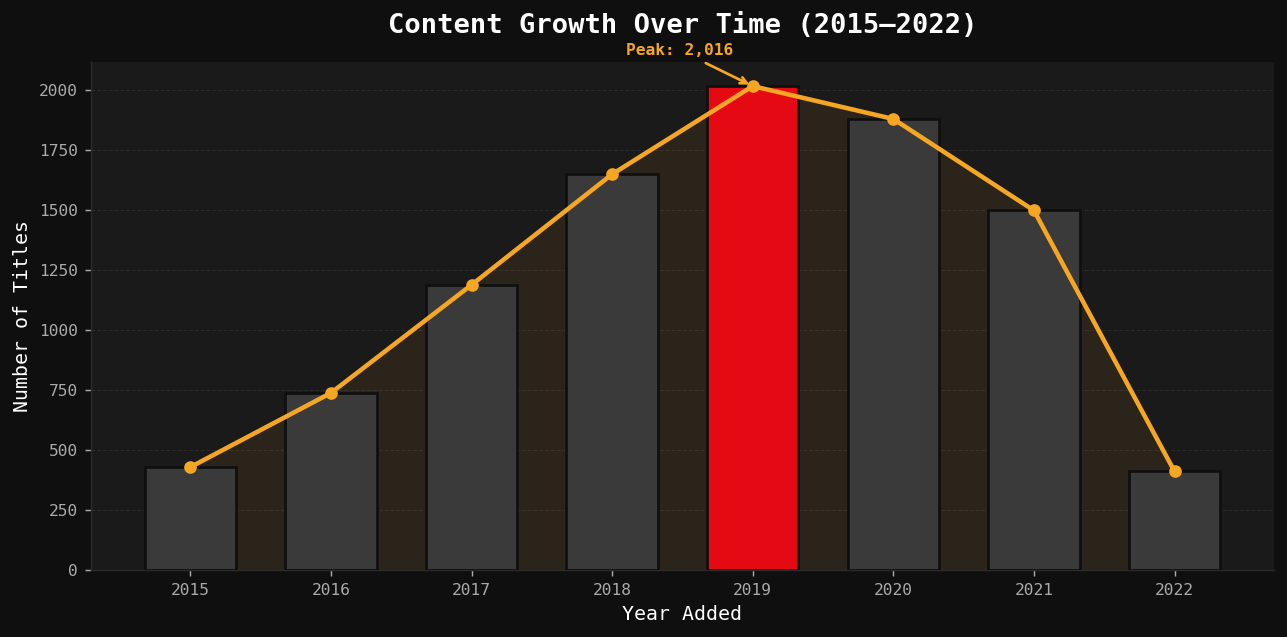

In [ ]:
year_counts = (
    df[(df["year_added"] >= 2015) & (df["year_added"] <= 2022)]
    ["year_added"].value_counts().sort_index()
)

fig, ax = plt.subplots(figsize=(10, 5))
bar_colors = [RED if y == year_counts.idxmax() else "#3A3A3A" for y in year_counts.index]
ax.bar(year_counts.index, year_counts.values, color=bar_colors,
       width=0.65, edgecolor=BG, linewidth=1.5, zorder=3)
ax.plot(year_counts.index, year_counts.values, color=GOLD, linewidth=2.5,
        marker="o", markersize=6, markerfacecolor=GOLD, zorder=4)
ax.fill_between(year_counts.index, year_counts.values, alpha=0.08, color=GOLD)
ax.set_axisbelow(True)
ax.yaxis.grid(True, linestyle="--")

peak_yr = year_counts.idxmax()
ax.annotate(f"Peak: {year_counts[peak_yr]:,}",
            xy=(peak_yr, year_counts[peak_yr]),
            xytext=(peak_yr - 0.9, year_counts[peak_yr] + 130),
            color=GOLD, fontsize=9, fontweight="bold",
            arrowprops=dict(arrowstyle="->", color=GOLD, lw=1.5))

for spine in ["top", "right"]: ax.spines[spine].set_visible(False)
ax.set_xlabel("Year Added"); ax.set_ylabel("Number of Titles")
ax.set_title("Content Growth Over Time (2015–2022)", fontsize=15, pad=16, fontweight="bold")
plt.tight_layout()
plt.show()


## 5. Geographic Analysis

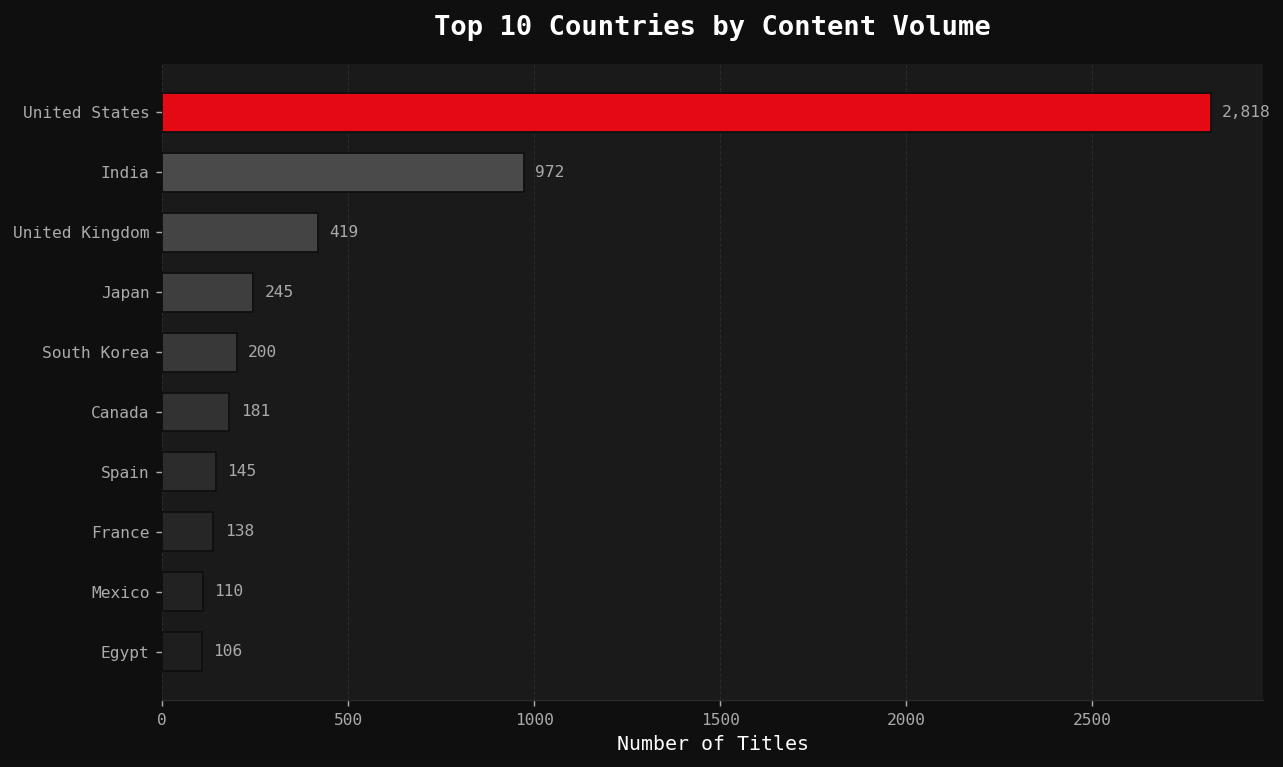

In [ ]:
df_exploded = df.copy()
df_exploded["country"] = df_exploded["country"].str.split(", ")
df_exploded = df_exploded.explode("country")
df_exploded = df_exploded[df_exploded["country"] != "Unknown"]

top10_countries = df_exploded["country"].value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 6))
bar_colors = [RED] + ["#333333"] * 9
hbars = ax.barh(top10_countries.index[::-1], top10_countries.values[::-1],
                color=bar_colors[::-1], edgecolor=BG, height=0.65)
for bar, val in zip(hbars, top10_countries.values[::-1]):
    ax.text(bar.get_width() + 30, bar.get_y() + bar.get_height()/2,
            f"{val:,}", va="center", color=MUTED, fontsize=9)

ax.set_axisbelow(True)
ax.xaxis.grid(True, linestyle="--")
for spine in ["top", "right", "left"]: ax.spines[spine].set_visible(False)
ax.set_xlabel("Number of Titles")
ax.set_title("Top 10 Countries by Content Volume", fontsize=15, pad=16, fontweight="bold")
plt.tight_layout()
plt.show()


## 6. Genre Analysis

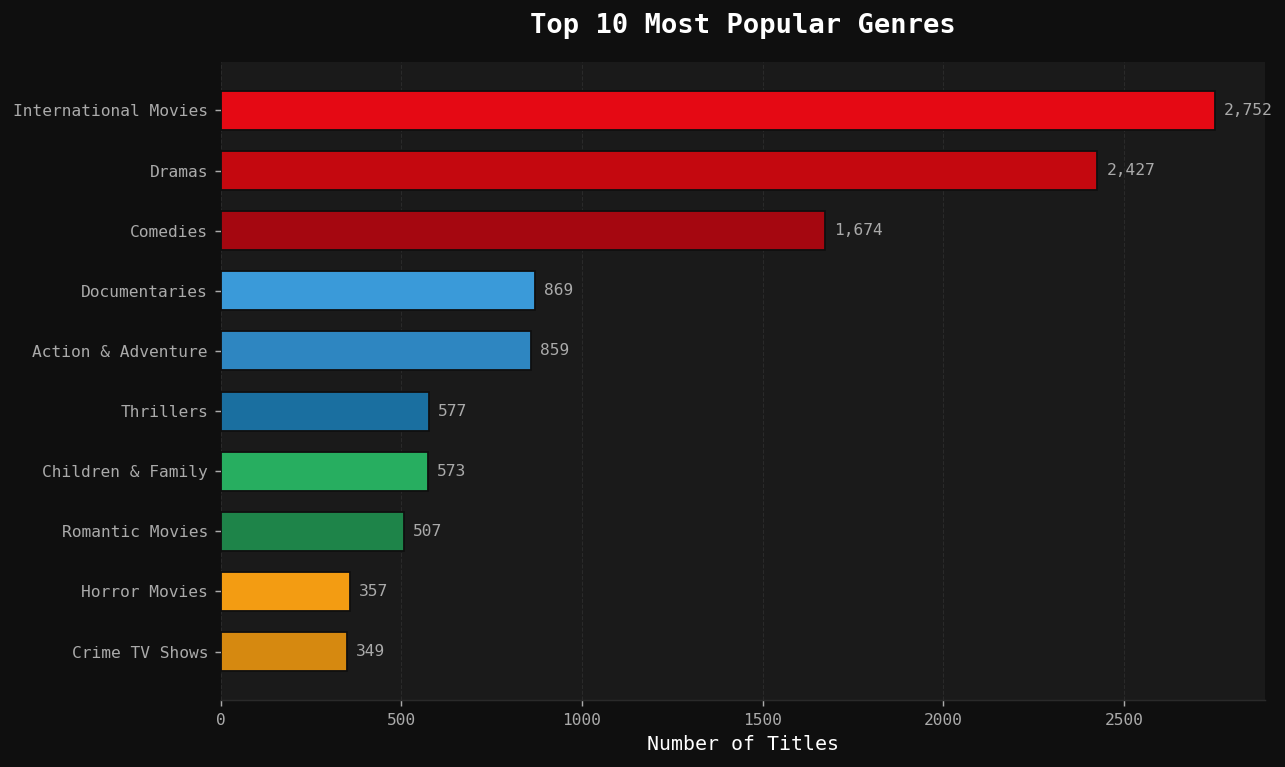

In [ ]:
genres_exploded = df["listed_in"].str.split(", ").explode()
top10_genres = genres_exploded.value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 6))
palette = [RED,"#C4080F","#A50710","#3A9AD9","#2E86C1",
           "#1A6FA0","#27AE60","#1E8449","#F39C12","#D68910"]
hbars = ax.barh(top10_genres.index[::-1], top10_genres.values[::-1],
                color=palette[::-1], edgecolor=BG, height=0.65)
for bar, val in zip(hbars, top10_genres.values[::-1]):
    ax.text(bar.get_width() + 25, bar.get_y() + bar.get_height()/2,
            f"{val:,}", va="center", color=MUTED, fontsize=9)

ax.set_axisbelow(True)
ax.xaxis.grid(True, linestyle="--")
for spine in ["top", "right", "left"]: ax.spines[spine].set_visible(False)
ax.set_xlabel("Number of Titles")
ax.set_title("Top 10 Most Popular Genres", fontsize=15, pad=16, fontweight="bold")
plt.tight_layout()
plt.show()


## 7. Rating & Duration Analysis

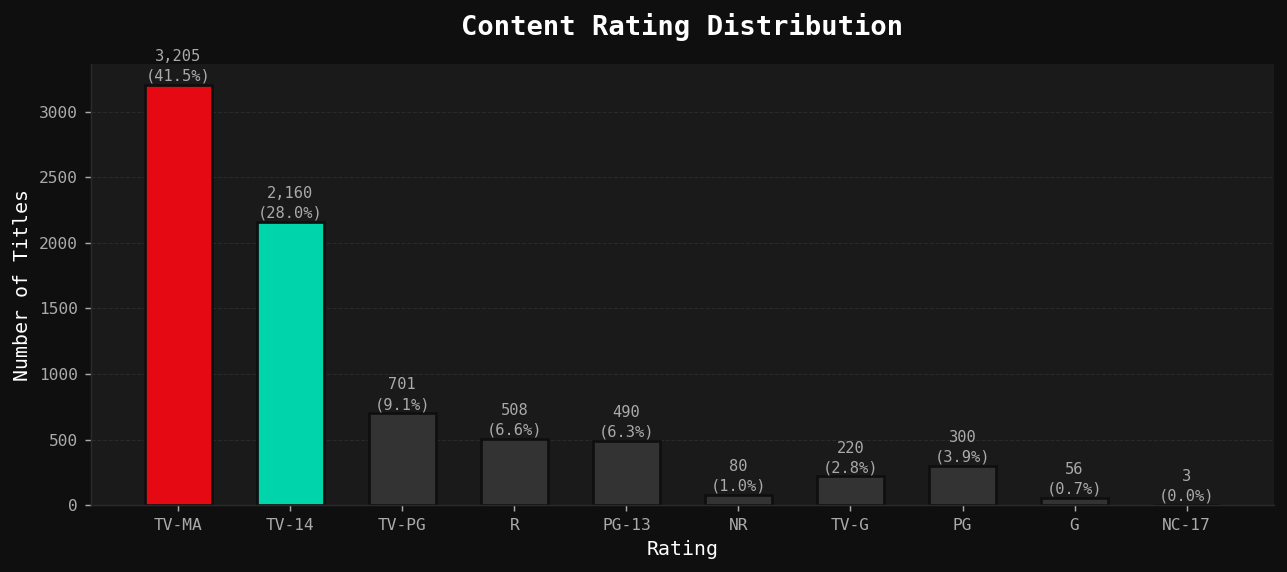

In [ ]:
rating_counts = df["rating"].value_counts().dropna()

fig, ax = plt.subplots(figsize=(10, 4.5))
colors_r = [RED if v == rating_counts.max()
            else ACCENT if v == sorted(rating_counts)[-2]
            else "#333333" for v in rating_counts]
bars = ax.bar(rating_counts.index, rating_counts.values,
              color=colors_r, edgecolor=BG, linewidth=1.5, width=0.6)
total_r = rating_counts.sum()
for bar, val in zip(bars, rating_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f"{val:,}\n({val/total_r:.1%})",
            ha="center", color=MUTED, fontsize=8.5, linespacing=1.4)
ax.set_axisbelow(True)
ax.yaxis.grid(True, linestyle="--")
for spine in ["top", "right"]: ax.spines[spine].set_visible(False)
ax.set_xlabel("Rating"); ax.set_ylabel("Number of Titles")
ax.set_title("Content Rating Distribution", fontsize=15, pad=16, fontweight="bold")
plt.tight_layout()
plt.show()


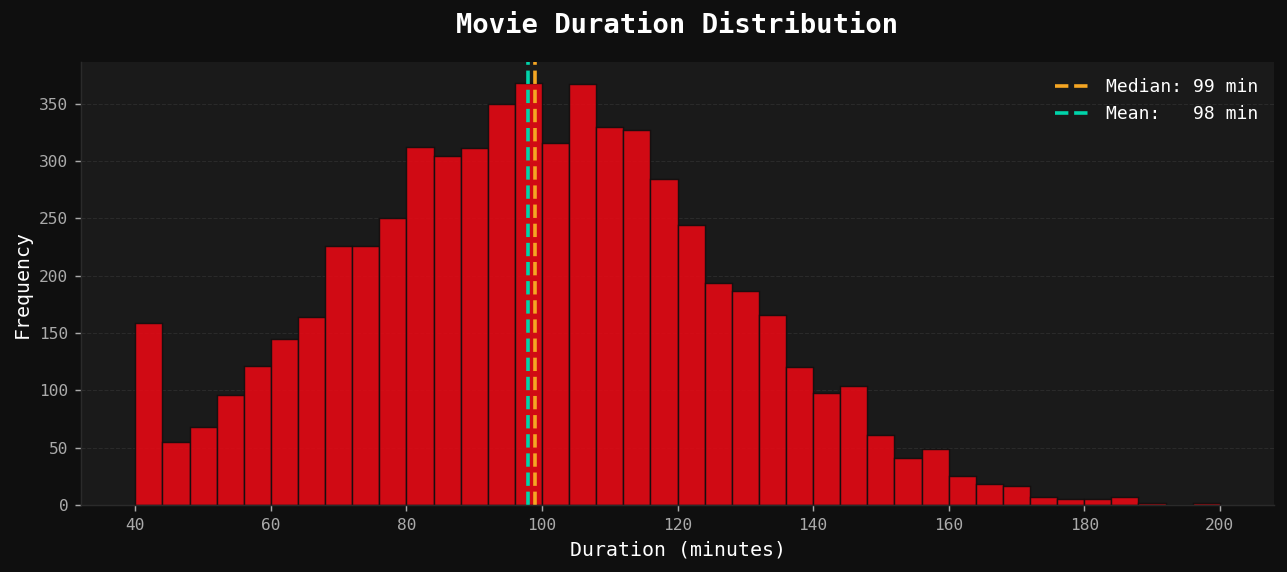

In [ ]:
movies_dur = (
    df[df["type"] == "Movie"]["duration"]
    .str.extract(r"(\d+)").astype(float).squeeze()
    .dropna()
)

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.hist(movies_dur, bins=40, color=RED, edgecolor=BG, linewidth=0.8, alpha=0.9)
med, mn = movies_dur.median(), movies_dur.mean()
ax.axvline(med, color=GOLD,  lw=2, linestyle="--", label=f"Median: {med:.0f} min")
ax.axvline(mn,  color=ACCENT, lw=2, linestyle="--", label=f"Mean:   {mn:.0f} min")
ax.legend(frameon=False, labelcolor=TEXT, fontsize=10)
ax.set_axisbelow(True)
ax.yaxis.grid(True, linestyle="--")
for spine in ["top", "right"]: ax.spines[spine].set_visible(False)
ax.set_xlabel("Duration (minutes)"); ax.set_ylabel("Frequency")
ax.set_title("Movie Duration Distribution", fontsize=15, pad=16, fontweight="bold")
plt.tight_layout()
plt.show()


## 8. Key Insights & Conclusions

---

### 📊 1 — Content Mix
Netflix's catalog skews heavily toward **movies (69.6%)** vs TV Shows (30.4%).  
This likely reflects lower licensing complexity and faster production cycles for films.

---

### 📈 2 — Growth Trajectory
Content additions grew **~4.7× between 2015 and 2019** (429 → 2,016 titles/year),  
signaling massive platform investment in that window.  
The 2020–2022 decline may reflect COVID production delays and post-saturation strategy shifts.

---

### 🌍 3 — Geographic Concentration
The **United States accounts for 32%** of all content, with India as a distant second (11%).  
Asian markets (Japan + South Korea) represent a growing strategic frontier.

---

### 🎭 4 — Genre Strategy
**International Movies** is the #1 genre — Netflix's global strategy is embedded in its content DNA.  
Drama + Comedy together cover ~46% of all titles, serving the broadest audience segments.

---

### 🔞 5 — Audience Targeting
**TV-MA (36.4%) + TV-14 (24.5%)** together represent 60%+ of the catalog,  
confirming Netflix's focus on adult and teen-adult audiences over family/children content.

---

### ⏱️ 6 — Movie Length
Average movie runtime of **~99 minutes** aligns precisely with the industry standard,  
suggesting Netflix's film acquisition/production mirrors theatrical norms rather than innovating on format.

---

> **Dataset:** [Netflix Movies and TV Shows — Kaggle](https://www.kaggle.com/datasets/shivamb/netflix-shows)  
> **Author:** Davi  
> **Tools:** Python · Pandas · Matplotlib · Seaborn
